# Statistical models to predict insurance claim severity

## Data acquisition and splitting

In [1]:
from _datapath import DATAPATH

In [2]:
import numpy as np
import os
import pandas as pd
from pathlib import Path

In [3]:
tables = os.listdir(DATAPATH)
datapath = Path(DATAPATH)

In [4]:
freq_df = pd.read_csv(datapath / tables[0])
sev_df = pd.read_csv(datapath / tables[1])

In [5]:
# freq_df.head()
# sev_df.head()
len(sev_df.index)

26639

In [6]:
df = freq_df.merge(sev_df, on='IDpol', how='left').fillna(0)
df.columns

Index(['IDpol', 'ClaimNb', 'Exposure', 'VehPower', 'VehAge', 'DrivAge',
       'BonusMalus', 'VehBrand', 'VehGas', 'Area', 'Density', 'Region',
       'ClaimAmount'],
      dtype='str')

In [7]:
df.head()

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region,ClaimAmount
0,1.0,1,0.10,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,0.0
1,3.0,1,0.77,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,0.0
2,5.0,1,0.75,6,2,52,50,B12,Diesel,B,54,Picardie,0.0
3,10.0,1,0.09,7,0,46,50,B12,Diesel,B,76,Aquitaine,0.0
4,11.0,1,0.84,7,0,46,50,B12,Diesel,B,76,Aquitaine,0.0


In [8]:
df['Exposure'].min()

np.float64(0.00273224)

In [9]:
len(df.IDpol.unique()), len(df.index)

(678013, 679513)

## Data Viz

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df.columns

Index(['IDpol', 'ClaimNb', 'Exposure', 'VehPower', 'VehAge', 'DrivAge',
       'BonusMalus', 'VehBrand', 'VehGas', 'Area', 'Density', 'Region',
       'ClaimAmount'],
      dtype='str')

<Axes: >

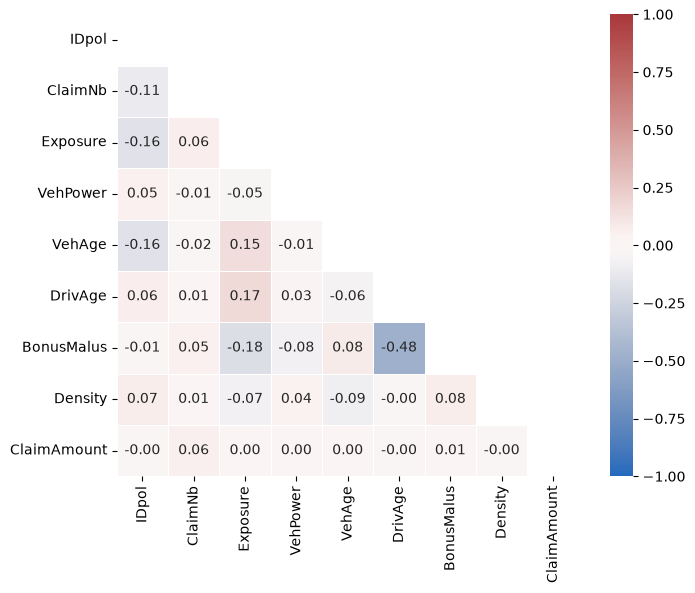

In [10]:
mask = np.triu(
    np.ones_like(
        df.corr(numeric_only=True)
    )
)
plt.figure(figsize=(8, 6))

# 5. Draw the heatmap
sns.heatmap(
    df.corr(numeric_only=True), 
    mask=mask, 
    annot=True,
    fmt=".2f", 
    cmap="vlag",
    vmin=-1, vmax=1, center=0, 
    square=True, 
    linewidths=.5 
)

In [11]:
# inspect total number of claims per categorical variable
cat_var = 'Region'
targ_var = 'ClaimNb'
df[[cat_var, targ_var]].groupby(cat_var).sum()

,ClaimNb
Region,
Alsace,151
Aquitaine,1496
Auvergne,201
Basse-Normandie,679
Bourgogne,545
Bretagne,2864
Centre,9640
Champagne-Ardenne,174
Corse,297


<Axes: xlabel='ClaimNb', ylabel='Region'>

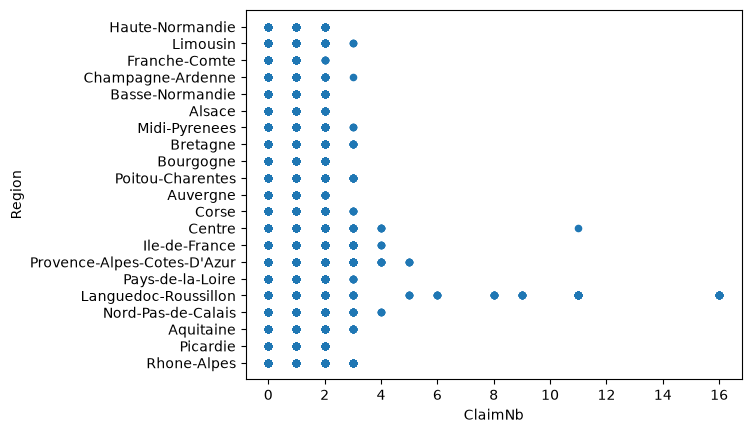

In [12]:
df.plot(x='ClaimNb', y='Region', kind='scatter')

/opt/homebrew/Caskroom/miniconda/base/envs/pymer4-env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
/opt/homebrew/Caskroom/miniconda/base/envs/pymer4-env/lib/python3.11/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_density : Removed 96086 rows containing non-finite values.


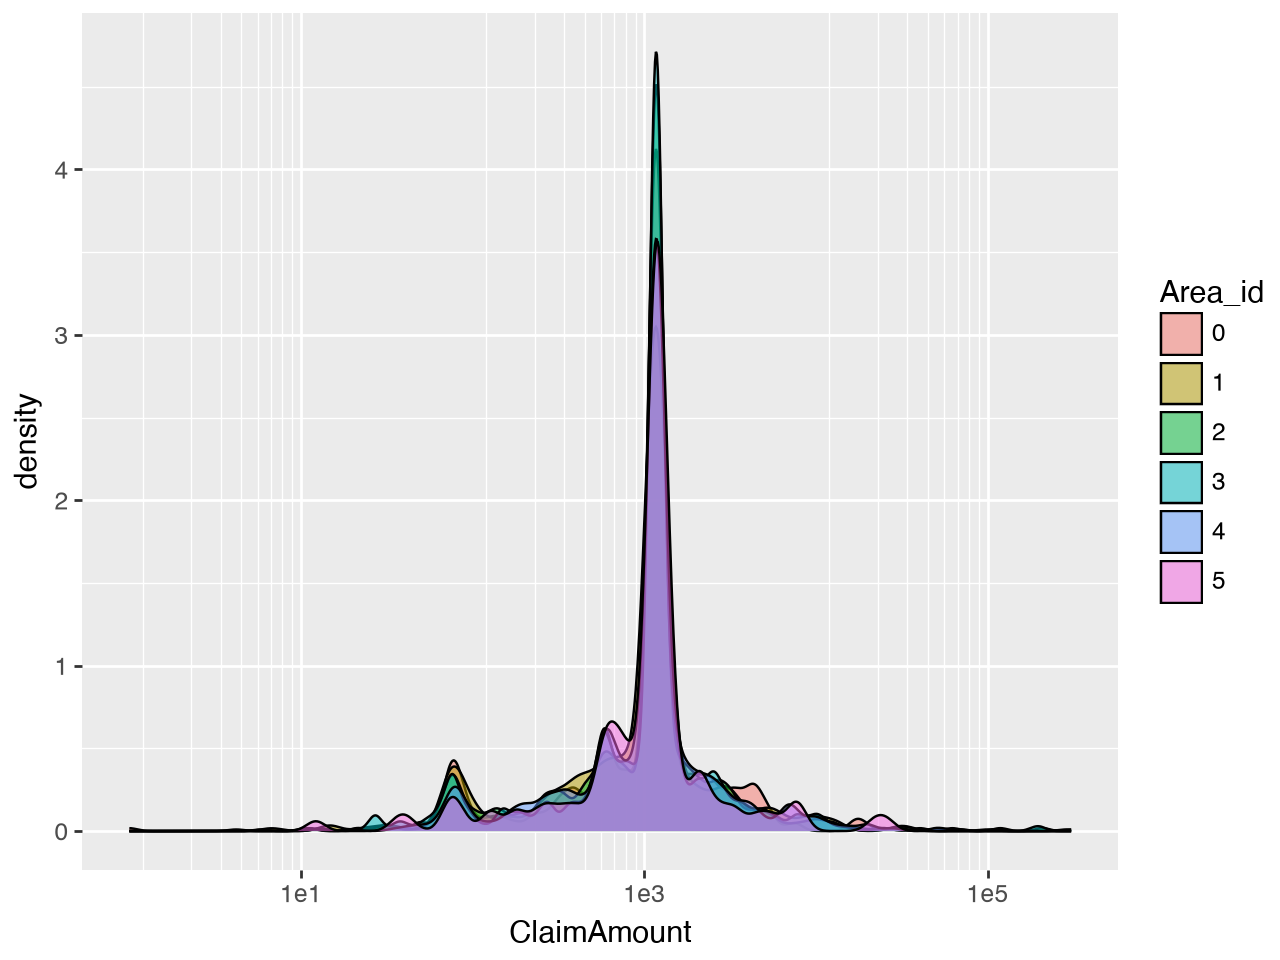

In [13]:
from plotnine import ggplot, aes, geom_density, facet_wrap, scale_x_log10

# explore target variables distribution per categorical variable
# categorical vars explored: 'VehBrand', 'VehGas', 'Area', 'Region'
# target variables: 'ClaimNb', 'ClaimAmount'

cat_var = 'Area'
targ_var = 'ClaimAmount'
cat_id_var = cat_var + '_id'
df[cat_id_var] = df[cat_var].astype('category').cat.codes.astype('category')

sampled_df = df.sample(n=100000)

(
    ggplot(sampled_df[[cat_id_var, targ_var]], aes(x=targ_var, fill=cat_id_var))
    + geom_density(alpha=0.5)
    + scale_x_log10()
)


### Conclusion for GLMMs:

From the exploration above we see that the distribution of Claim Numbers does generally depend on the values of most categorical variables. However, the distribution of Claim Amount is generally independent of VehBrand, VehGas, and Area. Region does seem to influence the distribution, but there is a general trend of having a peak at around 1000eur.

This means that in a GLMM predicting Claim Amount, we should use VehBrand, VehGas, and Area as random effects (tbd: potentially region could be useful too).

## General utilities

In [106]:
from sklearn.metrics import (
    max_error as me,
    mean_squared_error as mse, 
    mean_absolute_error as mae,
    mean_absolute_percentage_error as mape,
    explained_variance_score as evs,
    r2_score as r2,
    mean_poisson_deviance as mpd
)

def get_metrics_str(fitted_model, eval_data, target):
    y_pred = fitted_model.predict(exog=eval_data, offset=np.log(eval_data['Unscaled_Exposure']))
    y_true = eval_data[target]

    return f"""Model performace:
Max Error        = {me(y_true, y_pred): .4g}
MSE              = {mse(y_true, y_pred) : .4g}
MAE              = {mae(y_true, y_pred) : .4g}
Expl. Var. Score = {evs(y_true, y_pred) : .4g}
R2 Score         = {r2(y_true, y_pred) : .4g}
Mean Poiss. Dev. = {mpd(y_true, y_pred) : .4g}
Calibr. (pred / true total) = {y_pred.sum() / y_true.sum() }
"""


def get_metrics_str_pymer(fitted_model, eval_data, target):
    y_pred = fitted_model.predict(eval_data)
    y_true = eval_data[target]

    return f"""Model performace:
Max Error        = {me(y_true, y_pred): .4g}
MSE              = {mse(y_true, y_pred) : .4g}
MAE              = {mae(y_true, y_pred) : .4g}
Expl. Var. Score = {evs(y_true, y_pred) : .4g}
R2 Score         = {r2(y_true, y_pred) : .4g}
Mean Poiss. Dev. = {mpd(y_true, y_pred) : .4g}
Calibr. (pred / true total) = {y_pred.sum() / y_true.sum() }
"""


## Features

In [32]:
from sklearn.preprocessing import MinMaxScaler

def preprocess_data(df, features:list, targets: list, id_col: str = 'IDpol'):

    df = df[features+targets]
    #
    for col_name in df.select_dtypes(str).columns:
        df[col_name + '_id'] = df[col_name].astype('category').cat.codes.astype('category')

    categorical_df = df.select_dtypes(include=['category'])
    numerical_df = df.select_dtypes(include=['number'])
    exposure = df[['Exposure']]
    claimnb = df['ClaimNb']
    #
    scaler = MinMaxScaler()
    rescaled_num_df = pd.DataFrame(
        scaler.fit_transform(numerical_df), columns=numerical_df.columns
    )
    #
    full_data = rescaled_num_df.merge(categorical_df, left_index=True, right_index=True)
    for target in targets:
        full_data[target] = full_data.pop(target) # move targets to last position
    full_data['Unscaled_Exposure'] = exposure
    # full_data.drop('ClaimNb')
    full_data['ClaimNb'] = claimnb # also used unscaled ClaimNb
    return full_data

In [33]:
id_col = ['IDpol']
targets = ['ClaimNb', 'ClaimAmount']
features = [col for col in df.columns if col not in targets + id_col]

TARG_ID = 0 # start only training for one of the two targets
targ = [targets[TARG_ID]]

prepr_data = preprocess_data(df, features=features, targets=targ)
prepr_data.head()

,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density,VehBrand_id,VehGas_id,Area_id,Region_id,ClaimNb,Unscaled_Exposure
0,0.048458,0.090909,0.00,0.451220,0.0,0.045039,3,1,3,20,1,0.10
1,0.382245,0.090909,0.00,0.451220,0.0,0.045039,3,1,3,20,1,0.77
2,0.372281,0.181818,0.02,0.414634,0.0,0.001963,3,0,1,17,1,0.75
3,0.043476,0.272727,0.00,0.341463,0.0,0.002778,3,0,1,1,1,0.09
4,0.417118,0.272727,0.00,0.341463,0.0,0.002778,3,0,1,1,1,0.84


In [34]:
categorical_vars = [
    v for v in prepr_data.select_dtypes('category').columns.to_list()
    if v not in targets
]
numerical_vars = [
    v for v in prepr_data.select_dtypes('number').columns.to_list()
    if v not in targets
]
categorical_vars

['VehBrand_id', 'VehGas_id', 'Area_id', 'Region_id']

In [35]:
from sklearn.model_selection import train_test_split

tr_prepr_data, ev_prepr_data = train_test_split(prepr_data, train_size=0.8)

In [36]:
ev_prepr_data.head()

,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density,VehBrand_id,VehGas_id,Area_id,Region_id,ClaimNb,Unscaled_Exposure
157015,0.496828,0.181818,0.08,0.536585,0.000000,0.048594,0,0,3,6,0,1.00
380256,0.018566,0.000000,0.01,0.341463,0.116667,0.122227,3,1,4,14,0,0.04
668288,0.168023,0.545455,0.01,0.731707,0.000000,0.078373,3,1,4,11,0,0.34
280112,0.163041,0.454545,0.04,0.109756,0.277778,0.006148,7,1,2,16,0,0.33
517175,0.252716,0.363636,0.02,0.487805,0.011111,0.022556,3,0,3,19,1,0.51


## Fitting a GLM (with MLE)

In [37]:
import statsmodels.api as sm
import statsmodels.formula.api as smf


In [58]:
categorical_formula = ' + '.join([f'C({cat_var})' for cat_var in categorical_vars])
numerical_formula = ' + '.join([
    var for var in numerical_vars if var not in ['Unscaled_Exposure', 'Exposure']
]) # Exposure will be passed as an offset since probability / frequency scales with exposure time
formula = f'{targ[0]} ~ ' + numerical_formula + ' + ' + categorical_formula
print(formula)

ClaimNb ~ VehPower + VehAge + DrivAge + BonusMalus + Density + C(VehBrand_id) + C(VehGas_id) + C(Area_id) + C(Region_id)


In [59]:
fam = sm.families.Poisson()
print(fam.link) # log link

In [60]:
model = smf.glm(
    formula = formula, 
    data=tr_prepr_data,
    family = sm.families.Poisson(),
    offset=np.log(tr_prepr_data['Unscaled_Exposure'])
)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                ClaimNb   No. Observations:               543610
Model:                            GLM   Df Residuals:                   543568
Model Family:                 Poisson   Df Model:                           41
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.2447e+05
Date:                Wed, 16 Sep 2026   Deviance:                   1.9026e+05
Time:                        21:36:35   Pearson chi2:                 1.78e+06
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01244
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -2.4781      0.091    -27.083      0.000      -2.657      -2.299
C(VehBrand_id)[T.1]     -0.1068      0.040     -2.642      0.008      -0.186      -0.028
C(VehBrand_id)[T.2]      0.0546      0.042      1.303      0.192      -0.028       0.137
C(VehBrand_id)[T.3]      0.0771      0.019      4.163      0.000       0.041       0.113
C(VehBrand_id)[T.4]     -0.0278      0.044     -0.632      0.527      -0.114       0.058
C(VehBrand_id)[T.5]     -0.2761      0.086     -3.213      0.001      -0.445      -0.108
C(VehBrand_id)[T.6]     -0.0724      0.016     -4.485      0.000      -0.104      -0.041
C(VehBrand_id)[T.7]     -0.0612      0.023     -2.637      0.008      -0.107      -0.016
C(VehBrand_id)[T.8]     -0.1219      0.032     -3.805      0.000      -0.185      -0.059
C(VehBrand_id)[T.9]     -0.0181      0.027     -0.680      0.497      -0.070       0.034
C(VehBrand_id)[T.10]    -0.1036      0.030     -3.437      0.001      -0.163      -0.045
C(VehGas_id)[T.1]        0.0396      0.012      3.393      0.001       0.017       0.062
C(Area_id)[T.1]          0.0549      0.024      2.328      0.020       0.009       0.101
C(Area_id)[T.2]          0.0855      0.020      4.369      0.000       0.047       0.124
C(Area_id)[T.3]          0.2561      0.021     12.384      0.000       0.216       0.297
C(Area_id)[T.4]          0.2706      0.027      9.914      0.000       0.217       0.324
C(Area_id)[T.5]          0.3075      0.094      3.274      0.001       0.123       0.492
C(Region_id)[T.1]       -0.1749      0.092     -1.904      0.057      -0.355       0.005
C(Region_id)[T.2]       -0.3961      0.118     -3.362      0.001      -0.627      -0.165
C(Region_id)[T.3]       -0.0785      0.097     -0.811      0.418      -0.268       0.111
C(Region_id)[T.4]       -0.1036      0.099     -1.043      0.297      -0.298       0.091
C(Region_id)[T.5]       -0.0644      0.090     -0.718      0.473      -0.240       0.112
C(Region_id)[T.6]       -0.0694      0.088     -0.786      0.432      -0.242       0.104
C(Region_id)[T.7]        0.0503      0.122      0.412      0.680      -0.189       0.289
C(Region_id)[T.8]        0.1863      0.108      1.724      0.085      -0.025       0.398
C(Region_id)[T.9]       -0.1988      0.167     -1.187      0.235      -0.527       0.129
C(Region_id)[T.10]      -0.1643      0.107     -1.541      0.123      -0.373       0.045
C(Region_id)[T.11]      -0.0955      0.090     -1.067      0.286      -0.271       0.080
C(Region_id)[T.12]       0.2090      0.090      2.315      0.021       0.032       0.386
C(Region_id)[T.13]       0.0914      0.110      0.830      0.407      -0.124       0.307
C(Region_id)[T.14]      -0.2511      0.097     -2.595      0.009      -0.441      -0.061
C(Region_id)[T.15]      -0.2731      0.091     -3.008    

In [107]:
print(get_metrics_str(result, eval_data=ev_prepr_data, target=targets[TARG_ID]))


Model performace:
Max Error        =  15.96
MSE              =  0.07772
MAE              =  0.1069
Expl. Var. Score =  0.007313
R2 Score         =  0.007298
Mean Poiss. Dev. =  0.3486
Calibr. (pred / true total) = 1.0188679037999937



#### Note:

MAPE isn't a great metric here since percent errors normalized by the true value, which in many cases is 0.

<Axes: ylabel='Density'>

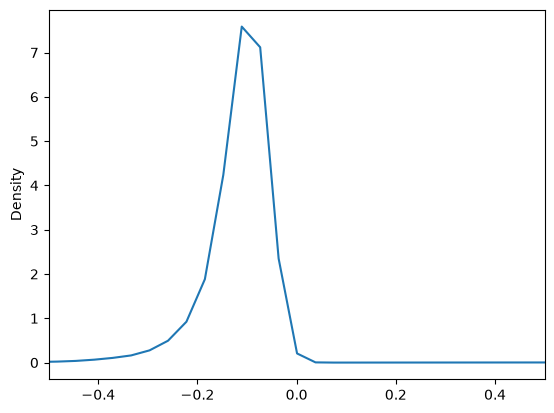

In [108]:
y_pred = result.predict(exog=ev_prepr_data)
y_true = ev_prepr_data[targets[TARG_ID]]
pd.DataFrame(
    {
        'y_true': y_true,
        'y_pred': y_pred,
        'diff': y_true - y_pred,
    }
)['diff'].plot(kind='density', xlim=(-0.5,0.5))

## Refining feature selection

In [109]:
# to pandas for row filtering
results_data = np.array(result.summary().tables[1].data)
results_df = pd.DataFrame(data=results_data[1:, 1:], index=results_data[1:, 0], columns=results_data[0, 1:])
results_df = results_df.apply(pd.to_numeric)

# list of predictor variables that had non-zero coefficients (p val = 0.01)
results_df[results_df['P>|z|'] < 0.01].index 

Index(['Intercept', 'C(VehBrand_id)[T.1]', 'C(VehBrand_id)[T.3]',
       'C(VehBrand_id)[T.5]', 'C(VehBrand_id)[T.6]', 'C(VehBrand_id)[T.7]',
       'C(VehBrand_id)[T.8]', 'C(VehBrand_id)[T.10]', 'C(VehGas_id)[T.1]',
       'C(Area_id)[T.2]', 'C(Area_id)[T.3]', 'C(Area_id)[T.4]',
       'C(Area_id)[T.5]', 'C(Region_id)[T.2]', 'C(Region_id)[T.14]',
       'C(Region_id)[T.15]', 'VehAge', 'DrivAge', 'BonusMalus'],
      dtype='str')

In [110]:
new_predictors = results_df[results_df['P>|z|'] < 0.01].index.to_list()[1:] # zeroth element of predictors is "Intercept" which is automatically added

# keep all levels for categorical data (syntax for level predictors is '{predictor name}[T.*]'):
new_predictors = np.unique([pred.split('[')[0] for pred in new_predictors])

new_formula = targets[TARG_ID] + ' ~ ' + ' + '.join(new_predictors) 
print(new_formula)

ClaimNb ~ BonusMalus + C(Area_id) + C(Region_id) + C(VehBrand_id) + C(VehGas_id) + DrivAge + VehAge


In [111]:
# new data split (reshuffle)
tr_prepr_data, ev_prepr_data = train_test_split(prepr_data, train_size=0.8)

In [112]:
model = smf.glm(
    formula = new_formula, 
    data=tr_prepr_data,
    family = sm.families.Poisson(),
    offset=np.log(tr_prepr_data['Unscaled_Exposure'])
).fit()

In [113]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                ClaimNb   No. Observations:               543610
Model:                            GLM   Df Residuals:                   543570
Model Family:                 Poisson   Df Model:                           39
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.2483e+05
Date:                Wed, 16 Sep 2026   Deviance:                   1.9104e+05
Time:                        22:16:34   Pearson chi2:                 1.79e+06
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01255
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -2.5017      0.092    -27.233      0.000      -2.682      -2.322
C(Area_id)[T.1]          0.0622      0.024      2.617      0.009       0.016       0.109
C(Area_id)[T.2]          0.1006      0.020      5.109      0.000       0.062       0.139
C(Area_id)[T.3]          0.2838      0.020     13.894      0.000       0.244       0.324
C(Area_id)[T.4]          0.2792      0.022     12.704      0.000       0.236       0.322
C(Area_id)[T.5]          0.2716      0.042      6.488      0.000       0.190       0.354
C(Region_id)[T.1]       -0.1366      0.092     -1.477      0.140      -0.318       0.045
C(Region_id)[T.2]       -0.3639      0.119     -3.068      0.002      -0.596      -0.131
C(Region_id)[T.3]       -0.0928      0.098     -0.950      0.342      -0.284       0.099
C(Region_id)[T.4]       -0.0717      0.100     -0.717      0.473      -0.268       0.124
C(Region_id)[T.5]       -0.0256      0.090     -0.283      0.777      -0.203       0.152
C(Region_id)[T.6]       -0.0523      0.089     -0.589      0.556      -0.227       0.122
C(Region_id)[T.7]        0.0701      0.123      0.571      0.568      -0.170       0.311
C(Region_id)[T.8]        0.1651      0.110      1.506      0.132      -0.050       0.380
C(Region_id)[T.9]       -0.1703      0.170     -0.999      0.318      -0.504       0.164
C(Region_id)[T.10]      -0.1473      0.108     -1.369      0.171      -0.358       0.064
C(Region_id)[T.11]      -0.0515      0.090     -0.571      0.568      -0.228       0.125
C(Region_id)[T.12]       0.2589      0.091      2.849      0.004       0.081       0.437
C(Region_id)[T.13]       0.1545      0.110      1.405      0.160      -0.061       0.370
C(Region_id)[T.14]      -0.1848      0.097     -1.905      0.057      -0.375       0.005
C(Region_id)[T.15]      -0.2395      0.091     -2.621      0.009      -0.419      -0.060
C(Region_id)[T.16]      -0.1229      0.091     -1.349      0.177      -0.301       0.056
C(Region_id)[T.17]      -0.0262      0.102     -0.257      0.797      -0.226       0.174
C(Region_id)[T.18]      -0.1172      0.095     -1.240      0.215      -0.302       0.068
C(Region_id)[T.19]      -0.0388      0.089     -0.434      0.664      -0.214       0.136
C(Region_id)[T.20]       0.0051      0.089      0.057      0.954      -0.169       0.180
C(VehBrand_id)[T.1]     -0.0754      0.039     -1.947      0.052      -0.151       0.001
C(VehBrand_id)[T.2]      0.0331      0.041      0.804      0.421      -0.048       0.114
C(VehBrand_id)[T.3]      0.0759      0.018      4.164      0.000       0.040       0.112
C(VehBrand_id)[T.4]     -0.0455      0.044     -1.039      0.299      -0.131       0.040
C(VehBrand_id)[T.5]     -0.2846      0.086     -3.324      0.001      -0.452      -0.117
C(VehBrand_id)[T.6]     -0.1077      0.016     -6.663    

In [114]:
print(get_metrics_str(result, eval_data=ev_prepr_data, target=targets[TARG_ID]))


# y_pred = model.predict(exog=ev_prepr_data)
# y_true = ev_prepr_data[targets[TARG_ID]]

# print(
# f"""
# Model performace:

# Max Error        = {me(y_true, y_pred): .4g}
# MSE              = {mse(y_true, y_pred) : .2g}
# MAE              = {mae(y_true, y_pred) : .2g}
# MAPE             = {mape(y_true, y_pred) : .2g}
# Expl. Var. Score = {evs(y_true, y_pred) : .2g}
# R2 Score         = {r2(y_true, y_pred) : .2g}
# """
# )

Model performace:
Max Error        =  15.96
MSE              =  0.07506
MAE              =  0.1082
Expl. Var. Score =  0.009928
R2 Score         =  0.009928
Mean Poiss. Dev. =  0.3492
Calibr. (pred / true total) = 0.9958132783667754



#### Analysis

Here, likelihood-based scores like the mean poisson deviation are most relevant. As we can see, for both GLM models we get a similar performance, so in summary: our more parsimonious model doen't actually improve performance (so overfitting wasn't a problem in the original model it seems). It also did not improve runtime, so the first (ostensibly naive) model might be generally a better choice here.

## Fitting a GLMM (with MLE)

Weirdly enough, although most of stats models lives in the frequentist side of things, it only has Bayesian estimators for GLMMs. Found an alternative, `pymer4` which wraps around R's `lme`.

In [115]:
from pymer4.models import glmer

In [116]:
pymer_formula =(
    "ClaimNb ~ "
    "offset(log(Unscaled_Exposure)) + VehPower + VehAge + DrivAge + BonusMalus + Density + "
    "(1|Region_id)"
)

In [117]:
tr_prepr_data['ClaimNb'].unique()

array([ 0,  1,  2,  3,  9,  8, 16, 11,  4,  5,  6])

In [118]:
import polars as pl

## pymer4 works internally with polars, so I need to move to polars for compatibility
tr_pl = pl.from_pandas(tr_prepr_data)

In [119]:
model = glmer(
    pymer_formula, 
    data=tr_pl,
    family='poisson',
)

In [120]:
summary = model.fit(summary=True)

R messages: 
Derivatives (gradient and/or Hessian) not available. Cannot assess
  convergence through gradient-based checks.

Convergence status
: [1] FALSE
attr(,"gradient")
[1] NA

R messages: 
Derivatives (gradient and/or Hessian) not available. Cannot assess
  convergence through gradient-based checks.

Convergence status
: [1] FALSE
attr(,"gradient")
[1] NA



In [121]:
print(model.result_fit) 

shape: (6, 8)
┌─────────────┬───────────┬───────────┬───────────┬───────────┬────────────┬─────┬─────────────┐
│ term        ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ z_stat     ┆ df  ┆ p_value     │
│ ---         ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---        ┆ --- ┆ ---         │
│ str         ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64        ┆ f64 ┆ f64         │
╞═════════════╪═══════════╪═══════════╪═══════════╪═══════════╪════════════╪═════╪═════════════╡
│ (Intercept) ┆ -2.420186 ┆ 0.034572  ┆ -2.487946 ┆ -2.352427 ┆ -70.004768 ┆ inf ┆ 0.0         │
│ VehPower    ┆ 0.067319  ┆ 0.030933  ┆ 0.006692  ┆ 0.127946  ┆ 2.176301   ┆ inf ┆ 0.029533    │
│ VehAge      ┆ -3.614292 ┆ 0.1127    ┆ -3.835179 ┆ -3.393405 ┆ -32.070105 ┆ inf ┆ 1.1516e-225 │
│ DrivAge     ┆ 0.574396  ┆ 0.033849  ┆ 0.508053  ┆ 0.640738  ┆ 16.969334  ┆ inf ┆ 1.3849e-64  │
│ BonusMalus  ┆ 4.206566  ┆ 0.057249  ┆ 4.09436   ┆ 4.318773  ┆ 73.478147  ┆ inf ┆ 0.0         │
│ Density     ┆ 

In [122]:
model.ranef_var

group,term,estimate,conf_low,conf_high
str,str,f64,f64,f64
"""Region_id""","""sd__(Intercept)""",0.128374,null,null


In [123]:
ev_pl = pl.from_pandas(ev_prepr_data)

# compare means just to be sure there's no separate offset argument
# ( 
#     model.predict(ev_pl).mean(),
#     ev_pl['ClaimNb'].mean()
# )

print(get_metrics_str_pymer(model, ev_pl, 'ClaimNb'))

Model performace:
Max Error        =  15.97
MSE              =  0.07504
MAE              =  0.1083
Expl. Var. Score =  0.01017
R2 Score         =  0.01017
Mean Poiss. Dev. =  0.3496
Calibr. (pred / true total) = 0.9963279861378423



#### Analysis

Not much is gained by adding a regional random effect.